In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/Global-YouTube-Statistics.csv", encoding="ISO-8859-1")
df.head()

,rank,Youtuber,subscribers,video views,category,Title,uploads,Country,Abbreviation,channel_type,...,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,T-Series,245000000,2.280000e+11,Music,T-Series,20082,India,IN,Music,...,2000000.0,2006.0,Mar,13.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
1,2,YouTube Movies,170000000,0.000000e+00,Film & Animation,youtubemovies,1,United States,US,Games,...,NaN,2006.0,Mar,5.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
2,3,MrBeast,166000000,2.836884e+10,Entertainment,MrBeast,741,United States,US,Entertainment,...,8000000.0,2012.0,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
3,4,Cocomelon - Nursery Rhymes,162000000,1.640000e+11,Education,Cocomelon - Nursery Rhymes,966,United States,US,Education,...,1000000.0,2006.0,Sep,1.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
4,5,SET India,159000000,1.480000e+11,Shows,SET India,116536,India,IN,Entertainment,...,1000000.0,2006.0,Sep,20.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880


<h1>barplot</h1>

In [3]:
top_countries = df["Country"].value_counts().nlargest(5).index
top_types = df["channel_type"].value_counts().nlargest(5).index

df_f = df[
    df["Country"].isin(top_countries) &
    df["channel_type"].isin(top_types)
]

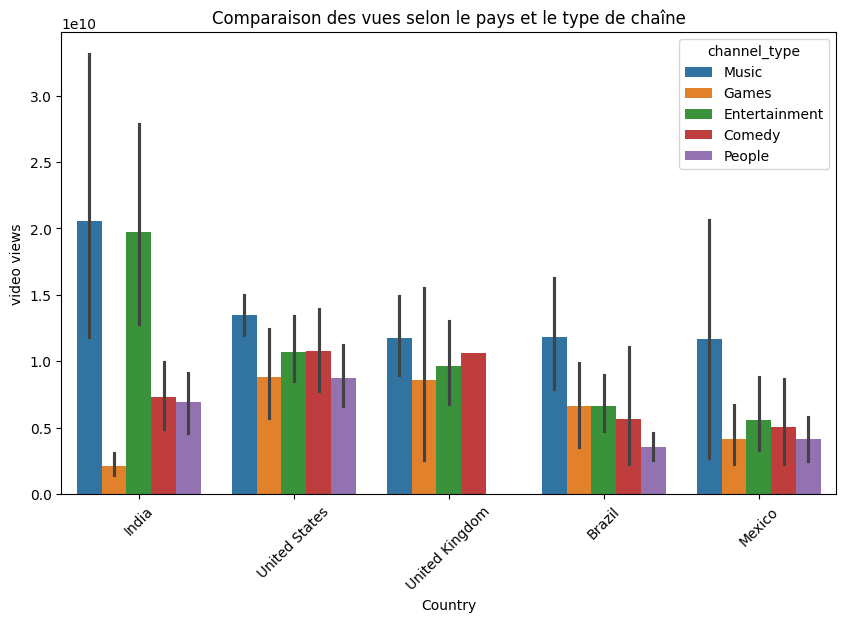

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.barplot(
    data=df_f,
    x="Country",
    y="video views",
    hue="channel_type",
    estimator="mean"
)

plt.title("Comparaison des vues selon le pays et le type de chaîne")
plt.xticks(rotation=45)

plt.show()

description 

Ce graphique est un diagramme en barres groupées.

L’axe horizontal représente les pays, et l’axe vertical montre le nombre de vues.

Chaque couleur correspond à un type de chaîne.

Les barres d’erreur indiquent la variation des données.

Ce graphique permet de comparer les vues selon le pays et le type de chaîne.

<h3>interprétation<h3>



*/L’Inde domine clairement en nombre de vues, surtout pour Music et Entertainment

*/Les chaînes Music sont les plus regardées dans presque tous les pays

*/Les Games ont généralement moins de vues comparées aux autres catégories

*/Les États-Unis et le Royaume-Uni ont des performances assez équilibrées entre les catégories

*/Le Brésil et le Mexique ont globalement moins de vues que les autres pays

*/Les catégories Comedy et People ont des vues moyennes à faibles dans tous les pays

*/Il existe une grande variation (barres d’erreur) surtout en Inde, ce qui montre des résultats très dispersés

<h1>violinplot</h1>

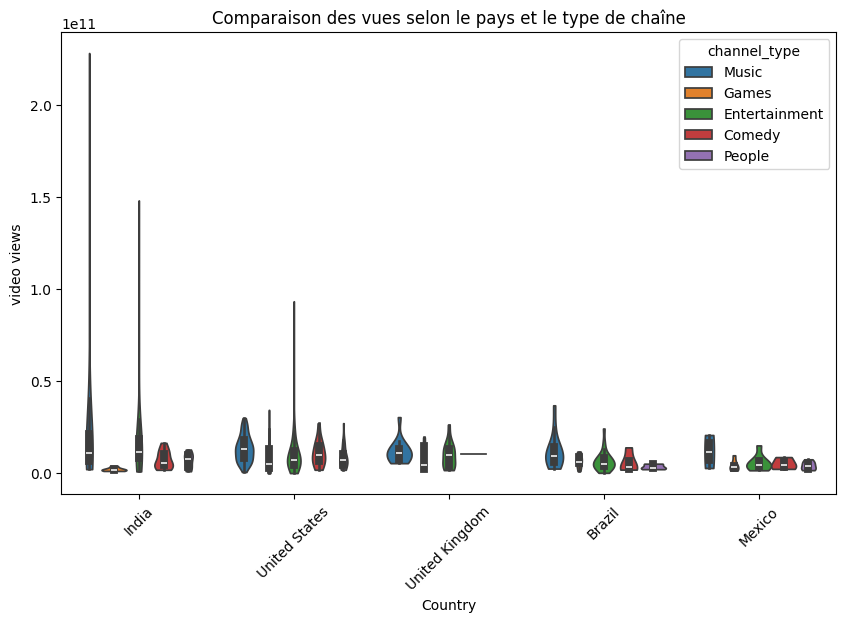

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.violinplot(
    data=df_f,
    x="Country",
    y="video views",
    hue="channel_type",
    cut=0  
)

plt.title("Comparaison des vues selon le pays et le type de chaîne")
plt.xticks(rotation=45)

plt.show()

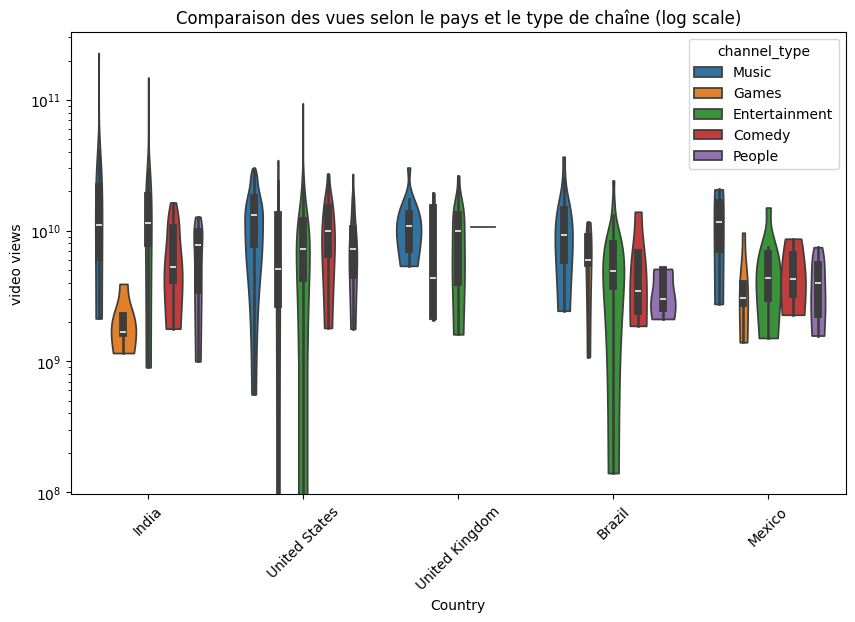

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.violinplot(
    data=df_f,
    x="Country",
    y="video views",
    hue="channel_type",
    cut=0  
)

plt.yscale('log')  

plt.title("Comparaison des vues selon le pays et le type de chaîne (log scale)")
plt.xticks(rotation=45)

plt.show()

<h3>interprétation<h3>

L’Inde a les vues les plus élevées avec une forte dispersion

Les États-Unis montrent aussi une variation importante mais moins que l’Inde

Le Royaume-Uni est plus stable (moins de variation)

Le Brésil et le Mexique ont des vues faibles

Music et Entertainment dominent

Présence de valeurs extrêmes (outliers)

<h3>décision<h3>

Il est recommandé de se concentrer sur les chaînes de type Music et Entertainment en ciblant principalement le marché indien.

<h1>Nuage de points multivarié (Scatter plot)</h1>

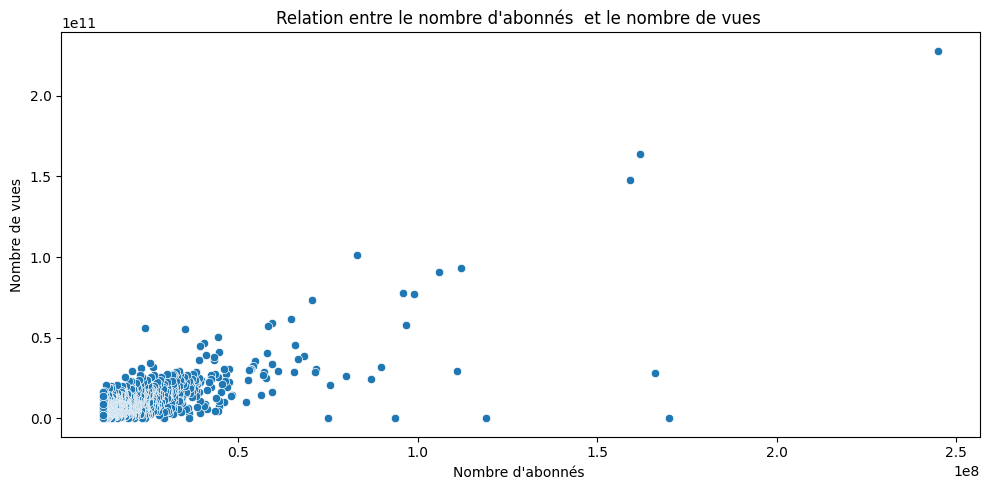

In [7]:
plt.figure(figsize=(10,5))

sns.scatterplot(data=df,x="subscribers",y="video views",)

plt.title("Relation entre le nombre d'abonnés  et le nombre de vues ", fontsize=12)
plt.xlabel("Nombre d'abonnés ")
plt.ylabel("Nombre de vues")

plt.tight_layout()
plt.show()

<h3>Interpretation</h3>

- Une Tendance positive lineare entre le nombre d'abonnés et le nombre de vues c-à-d lorsque le nombre d'abonnés augmente, le nombre de vues augmente.

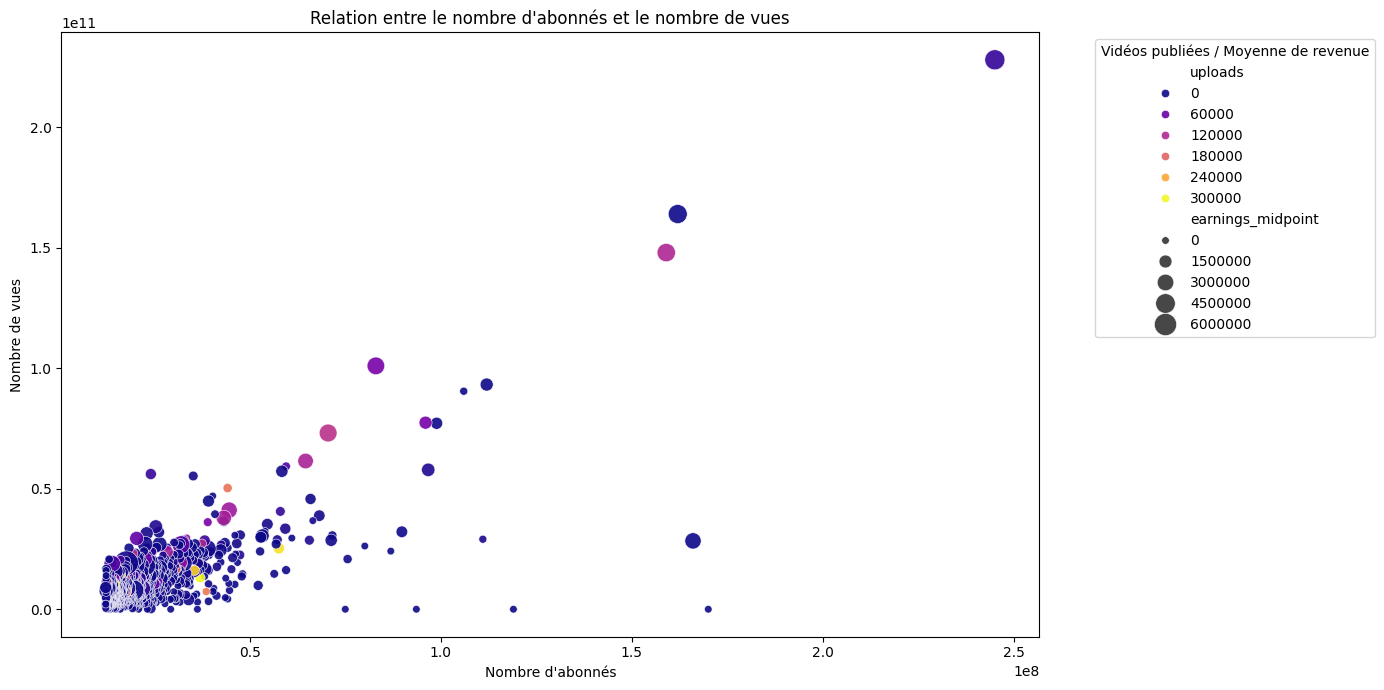

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
df["earnings_midpoint"] = (df["lowest_monthly_earnings"] + df["highest_monthly_earnings"]) / 2
plt.figure(figsize=(14,7))

sns.scatterplot(
    data=df,
    x="subscribers",
    y="video views",
    hue="uploads",
    size="earnings_midpoint",
    sizes=(30, 300),
    alpha=0.9,
    palette="plasma"
)

plt.title("Relation entre le nombre d'abonnés et le nombre de vues", fontsize=12)
plt.xlabel("Nombre d'abonnés")
plt.ylabel("Nombre de vues")

plt.legend(title="Vidéos publiées / Moyenne de revenue", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

<h3>Interpretation</h3>

- La majorité des chaînes YouTube ont des uploads compris entre 0 et 60000. On observe également une concentration moyenne entre 120000 et 240000, tandis qu’un nombre très faible de chaînes ont publié plus de 340000 vidéos.

- La plupart des chaînes ayant un nombre élevé de vues et d’abonnés présentent également une moyenne de revenus élevée, avec la présence de quelques cas exceptionnels.

- Le nombre de vues influence sur la moyenne du revenu.

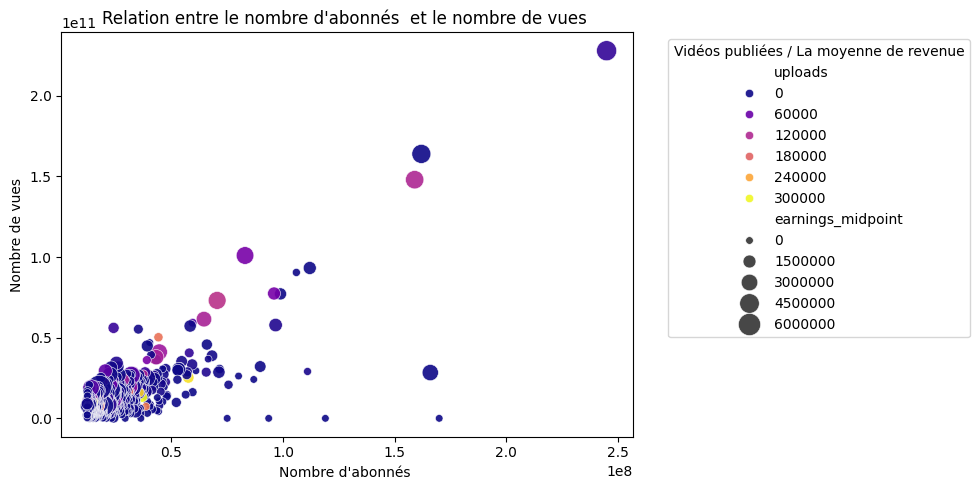

In [9]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    data=df,
    x="subscribers",
    y="video views",
    hue="uploads",
    size="earnings_midpoint",
    sizes=(30, 300),
    alpha=0.9,
    palette="plasma"
)

plt.title("Relation entre le nombre d'abonnés  et le nombre de vues ", fontsize=12)
plt.xlabel("Nombre d'abonnés ")
plt.ylabel("Nombre de vues")

plt.legend(title="Vidéos publiées / La moyenne de revenue", bbox_to_anchor=(1.05, 1), loc='upper left')

# plt.ylim(100,250)

plt.tight_layout()
plt.show()

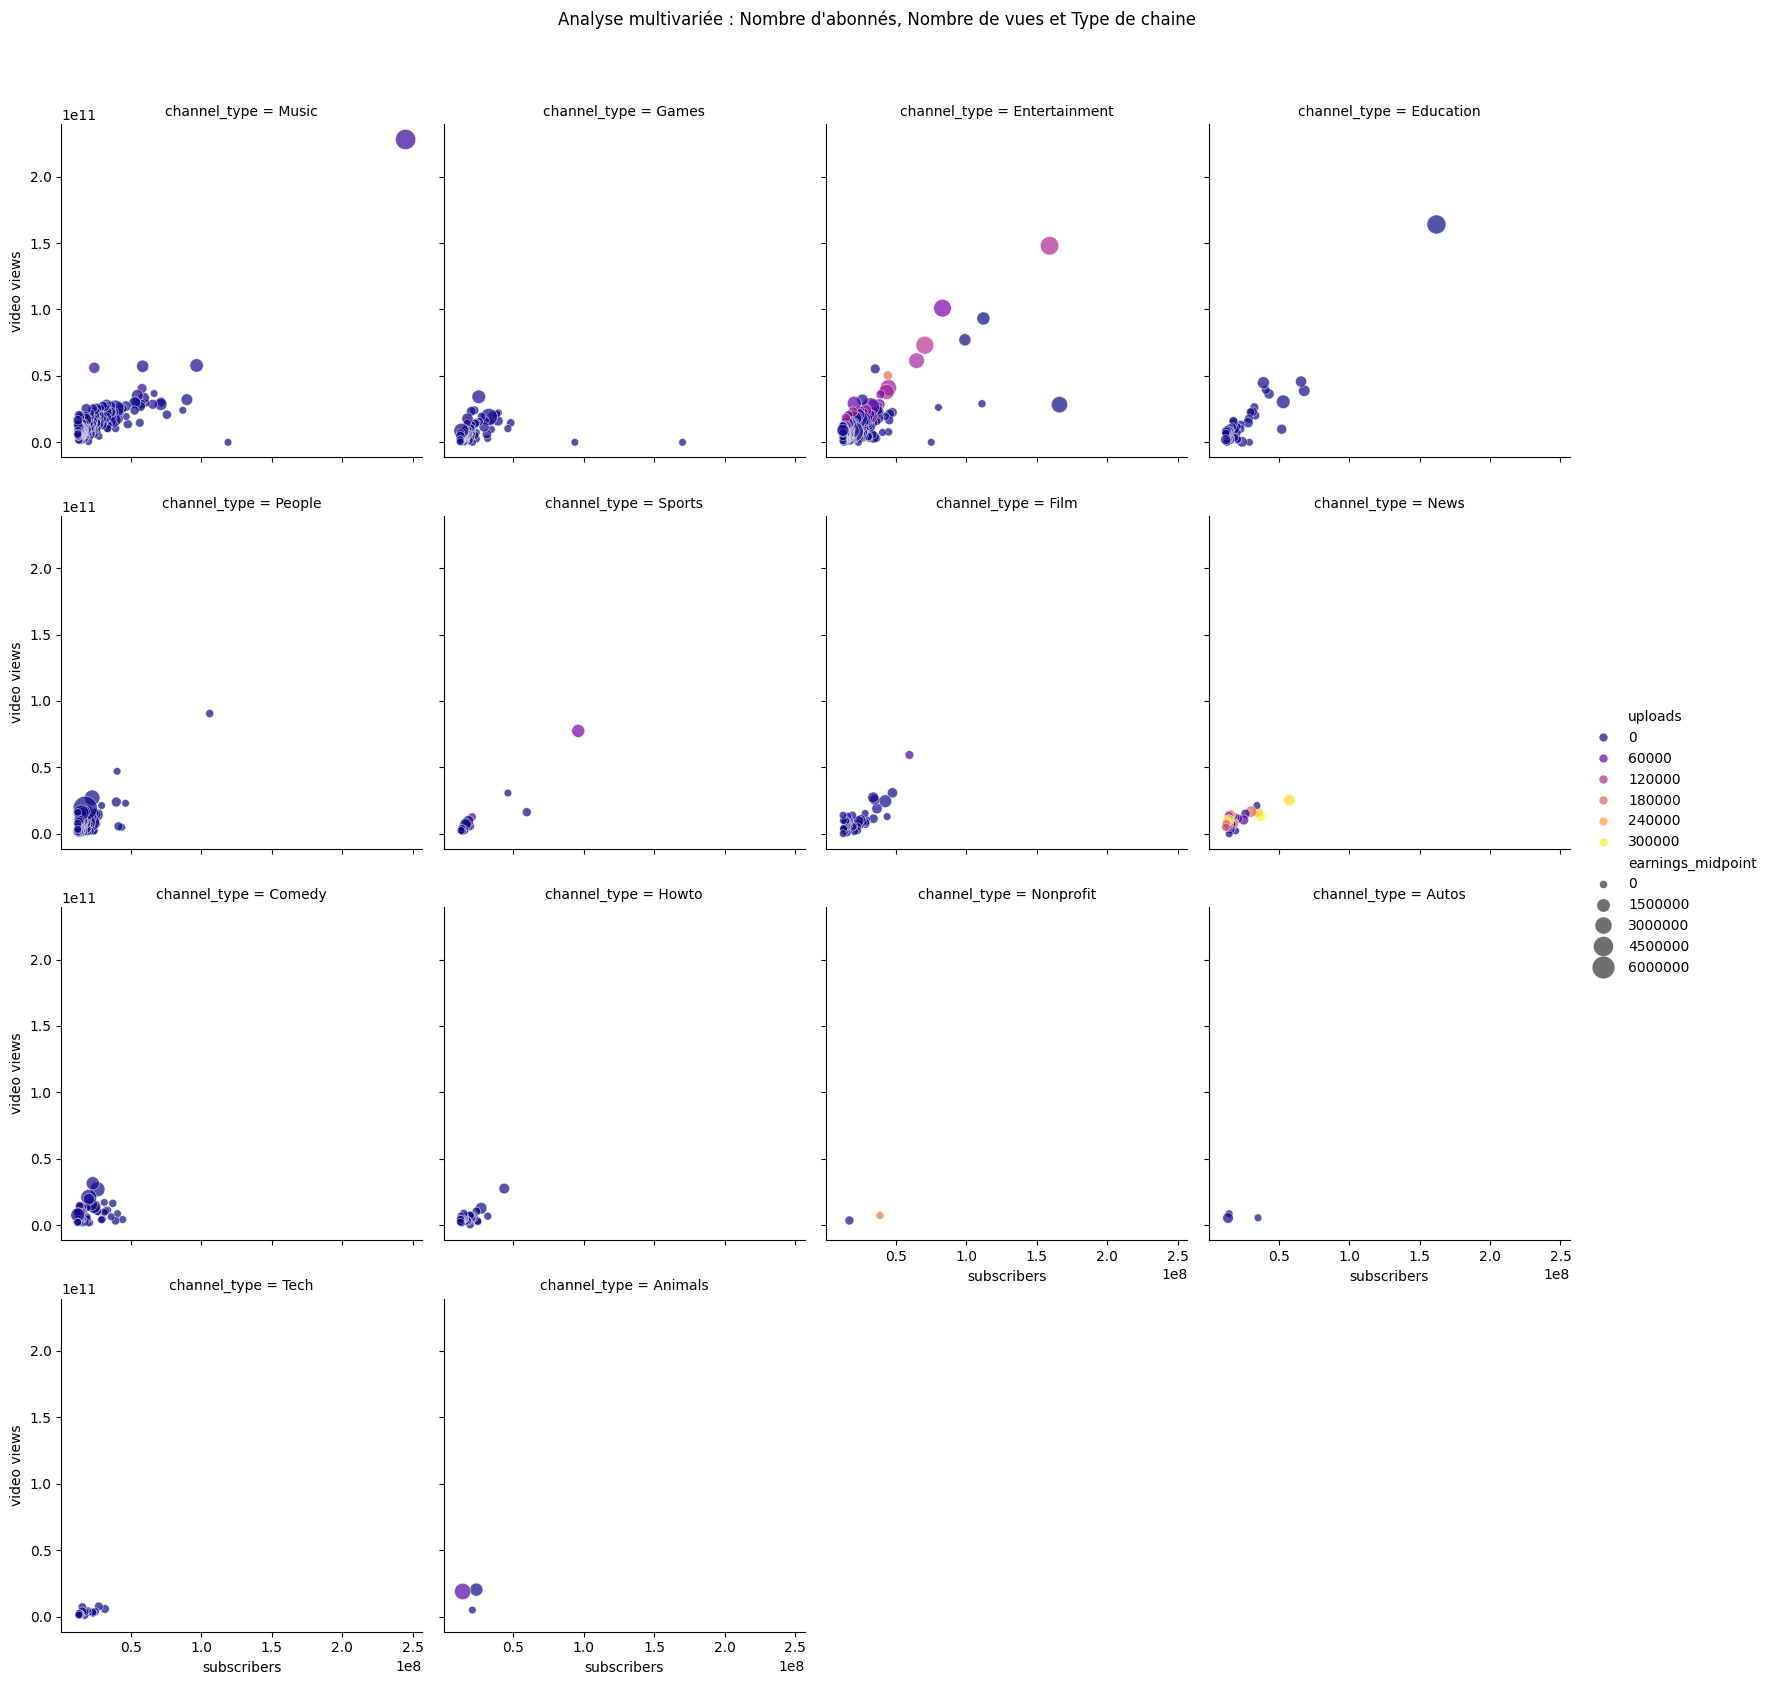

In [10]:
g = sns.relplot(
    data=df,
    x="subscribers",
    y="video views",
    hue="uploads",
    size="earnings_midpoint",
    col="channel_type", 
    col_wrap=4,
    sizes=(30, 300),
    alpha=0.7,
    height=4,
    palette="plasma"
)

g.fig.suptitle("Analyse multivariée : Nombre d'abonnés, Nombre de vues et Type de chaine", y=1.05)

plt.show()

<h3>Interpretation</h3>

- Une tendance reste similaire (tendance positive lineaire).

- La majorité des chaînes ayant un nombre d’uploads compris entre 0 et 60 000 sont de type Music, Games et Education, tandis que d’autres chaînes ayant publié un nombre moyen ou plus élevé de vidéos sont principalement de type News.

- Les chaînes ayant une moyenne de revenus élevée sont principalement de type Music et People, tandis que les autres catégories présentent une moyenne de revenus plus faible

<h1>ACP (Analyse en Composantes Principales)</h1>

Variance expliquée : [0.54681825 0.2423848 ]


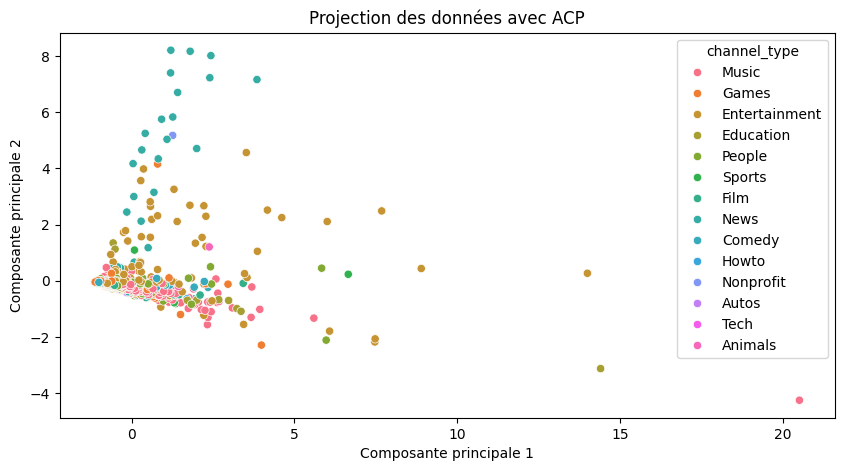


Contribution des variables :
     subscribers  video views   uploads  earnings_midpoint
PC1     0.569680     0.620799  0.194525           0.502228
PC2    -0.249577    -0.118294  0.959367           0.057733


In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
# Sélection des variables numériques
cols = ["subscribers","video views","uploads","earnings_midpoint"]

X = df[cols]

# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ACP (2 composantes)
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

# DataFrame PCA
df_pca = pd.DataFrame(components, columns=["PC1","PC2"])
df_pca["channel_type"] = df["channel_type"]

# Variance expliquée
print("Variance expliquée :", pca.explained_variance_ratio_)

# Visualisation
plt.figure(figsize=(10,5))

sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="channel_type"
)

plt.title("Projection des données avec ACP")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")

plt.show()

# Contribution des variables
contributions_vars = pd.DataFrame(
    pca.components_,
    columns=cols,
    index=["PC1","PC2"]
)

print("\nContribution des variables :")
print(contributions_vars)

<h3>Interpretation</h3>

- Le PC1 explique environ 54 % des informations.

- Le PC2 explique environ 24 % des informations.

- On garde environ 78 % des informations.

- Le PC1 représente la popularité globale (subscribers, video views et earnings_midpoint qui dominent).

- Le PC2 représente l'activité de Youtubers (uploads sont très dominantes).

<h2>Décision : </h2>

1) Creer un contenu attirant de type Music ,Education et Entertainment pour augmenter les vues et maximiser les revenues.

2) Construire un modèle de prédiction des revenus basé sur les abonnés et les vues (PC1). 

3) Investir dans la publicité, les collaborations et les influenceurs.



## Pairplot


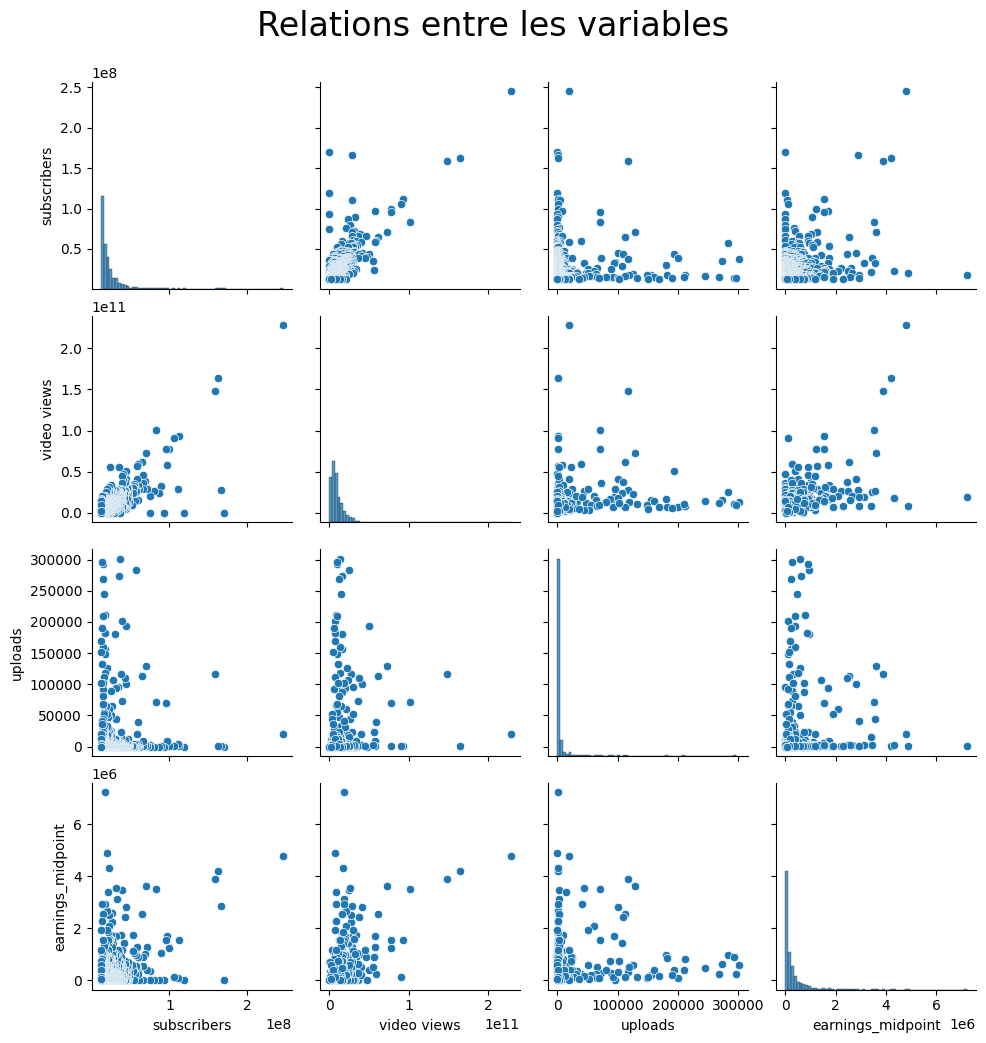

In [12]:
cols = ['subscribers', 'video views', 'uploads', 'earnings_midpoint', 'channel_type']
f = sns.pairplot(df[cols])

f.fig.suptitle("Relations entre les variables", y=1.04, fontsize=24)

plt.show()



## Interpretation


1. La Corrélation Majeure : Vues et  Revenus
C'est la relation la plus forte et la plus directe du graphique. Le nuage de points dessine une ligne montante très nette.

Conclusion : Le nombre de vues est le moteur principal de l'argent gagné. Plus une chaîne est regardée, plus elle génère de revenus.

2. La Corrélation Secondaire : Abonnés et Vues
Il existe une relation logique mais moins stricte entre les abonnés et les vues.

Conclusion : Avoir beaucoup d'abonnés aide à avoir des vues, mais ce n'est pas automatique. Certaines petites chaînes font des "coups d'éclat" avec énormément de vues sans avoir une grande base d'abonnés.

3. L'Absence de Relation : Uploads et Reste
Le nombre de vidéos publiées (uploads) n'a aucune influence réelle sur les abonnés, les vues ou les revenus.

Conclusion : La qualité l'emporte sur la quantité. Poster des milliers de vidéos ne garantit absolument pas le succès financier ou la popularité.

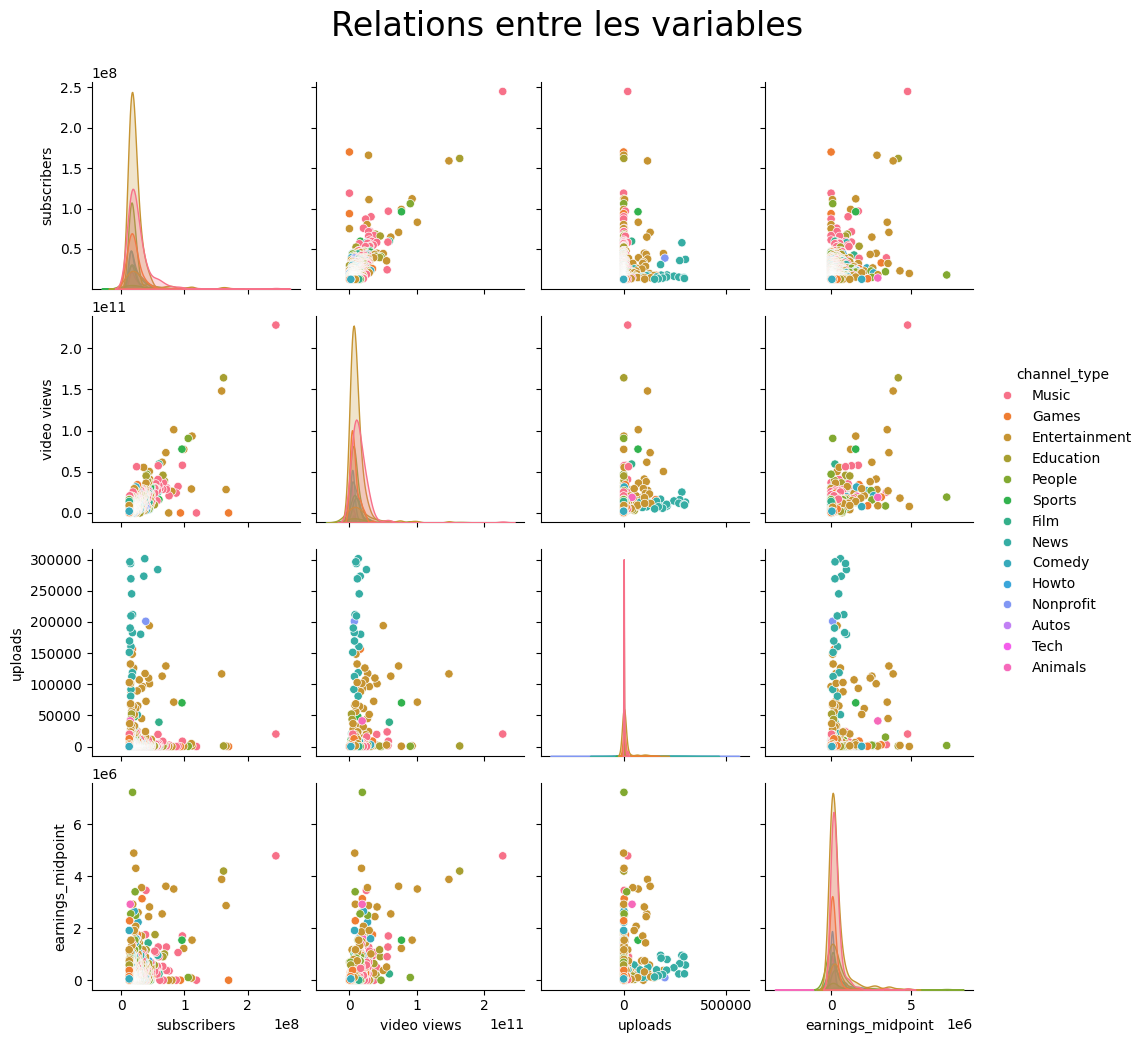

In [13]:
f = sns.pairplot(df[cols], hue="channel_type")

f.fig.suptitle("Relations entre les variables", y=1.04, fontsize=24)

plt.show()

## Interpretation

Dominance : Les catégories Music et Entertainment sont les leaders incontestés (plus de vues, d'abonnés et de revenus).

Stratégie : Les chaînes de News privilégient la quantité (plus d'uploads), mais cela ne garantit pas des revenus supérieurs.

Corrélation Clé : Le nombre de vues reste le seul indicateur fiable des revenus, peu importe le type de chaîne.

Efficacité : Le divertissement génère plus de profit avec moins de vidéos produites que l'information.

### Analyser les dependances - Heatmap

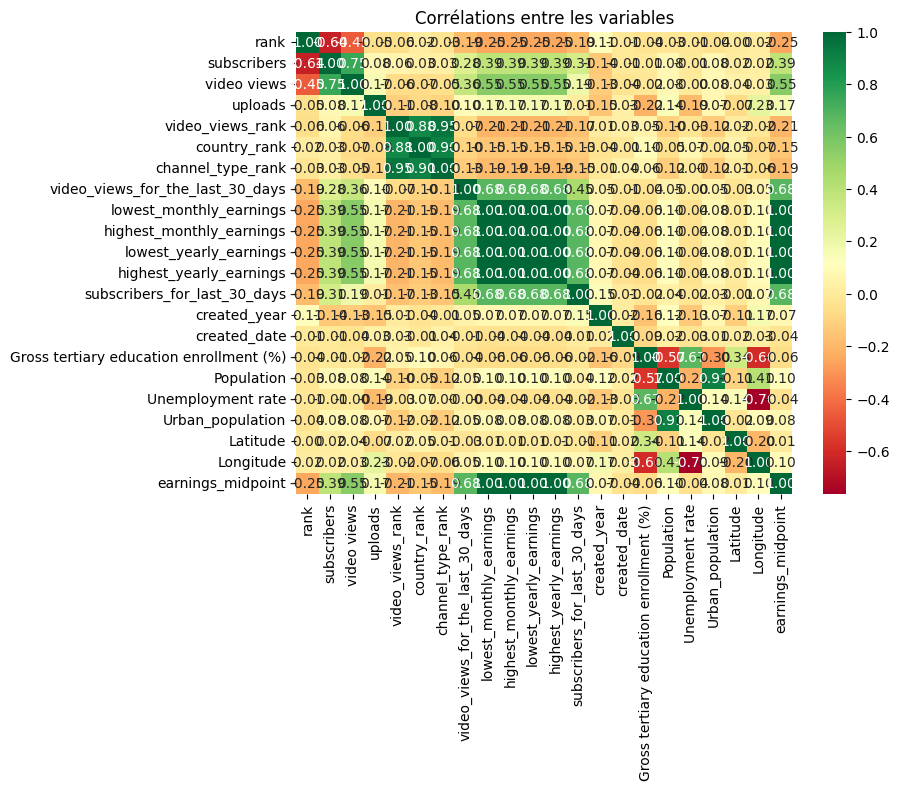

In [14]:
plt.figure(figsize=(8,6))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="RdYlGn",
    fmt=".2f"
)

plt.title("Corrélations entre les variables")
plt.show()

## Interpretation 

Lien Fort (0.75) : Plus on a d'abonnés, plus on a de vues. C'est la base de la croissance sur la plateforme.

Lien Moyen (0.55) : Les vues influencent les revenus, mais ce n'est pas automatique (cela dépend de la publicité et de l'origine de l'audience).

Lien Faible (0.08 / 0.17) : Le nombre de vidéos postées (uploads) n'a quasiment aucun impact sur le succès ou l'argent gagné.

Conclusion : Le succès se mesure aux vues et aux abonnés, pas à la quantité de vidéos produites.

## Prise de decision 

1. Stratégie de Contenu : "Qualité > Quantité"
Observation : La corrélation entre le nombre de vidéos postées (uploads) et le succès est quasiment nulle (0.08 à 0.17).

Décision : Ne pas chercher à publier massivement. Il est plus rentable de produire moins de vidéos mais de meilleure qualité pour maximiser les vues, car c'est le seul levier réel des revenus (0.55).

2. Choix du Créneau : Priorité au Divertissement
Observation : Les catégories Music et Entertainment dominent largement les abonnés et les revenus avec un effort de production moindre que les News.

Décision : Si l'objectif est la croissance rapide et la rentabilité, il faut privilégier ces thématiques "grand public" qui bénéficient d'un effet viral plus fort.

3. Nettoyage Technique de la Dataset
Observation : Les trois variables de revenus sont corrélées à 1.00 (relation parfaite).

Décision : Supprimer lowest_yearly_earnings et highest_yearly_earnings. Garder uniquement earnings_midpoint pour simplifier les calculs et éviter d'encombrer les futurs graphiques.


<div style="border-left:6px solid #7fb3d5; padding:12px; background:#f4f8fb; border-radius:10px; max-width:98%">
<b>1) Importation des bibliothèques et réglage du style</b>
</div>


In [15]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

sns.set_theme(style="whitegrid", context="talk")

def human_format(x, pos=None):
    if x >= 1e9:
        return f"{x/1e9:.1f}B"
    if x >= 1e6:
        return f"{x/1e6:.1f}M"
    if x >= 1e3:
        return f"{x/1e3:.0f}K"
    return f"{x:.0f}"



<div style="border-left:6px solid #7fb3d5; padding:12px; background:#f4f8fb; border-radius:10px; max-width:98%">
<b>3) Préparation des variables</b>
</div>

Nous créons le revenu médian estimé, puis nous filtrons les valeurs manquantes.  
Pour éviter une visualisation surchargée, nous gardons les pays les plus représentés.


In [17]:

df = df.copy()

# Création du revenu médian estimé
df["earnings_midpoint"] = (
    df["lowest_yearly_earnings"] + df["highest_yearly_earnings"]
) / 2

# Colonnes utiles
cols_needed = [
    "Youtuber",
    "video views",
    "earnings_midpoint",
    "Country",
    "Population",
    "channel_type"
]

df_vis = df[cols_needed].copy()

# Nettoyage
df_vis = df_vis.dropna(subset=["video views", "earnings_midpoint", "Country", "Population"])
df_vis = df_vis[
    (df_vis["video views"] > 0) &
    (df_vis["earnings_midpoint"] > 0) &
    (df_vis["Population"] > 0)
].copy()

# Sélection des pays les plus représentés
top_n_countries = 6
selected_countries = (
    df_vis["Country"]
    .value_counts()
    .head(top_n_countries)
    .index
)

df_sel = df_vis[df_vis["Country"].isin(selected_countries)].copy()

# Tableau résumé par pays
country_summary = (
    df_sel.groupby("Country", as_index=False)
    .agg(
        nb_chaines=("Youtuber", "count"),
        population=("Population", "first"),
        vues_medianes=("video views", "median"),
        revenu_median=("earnings_midpoint", "median")
    )
    .sort_values("nb_chaines", ascending=False)
)

print("Pays sélectionnés :", list(selected_countries))
display(country_summary)


Pays sélectionnés : ['United States', 'India', 'Brazil', 'United Kingdom', 'Mexico', 'Indonesia']


,Country,nb_chaines,population,vues_medianes,revenu_median
5,United States,294,3.282395e+08,8.828659e+09,2019600.0
1,India,163,1.366418e+09,7.876741e+09,2814700.0
0,Brazil,58,2.125594e+08,5.279167e+09,1275425.0
4,United Kingdom,43,6.683440e+07,9.808676e+09,1381450.0
3,Mexico,29,1.260140e+08,5.019137e+09,850400.0
2,Indonesia,27,2.702039e+08,4.526272e+09,1168700.0



<div style="border-left:6px solid #7fb3d5; padding:12px; background:#f4f8fb; border-radius:10px; max-width:98%">
<b>4) Objectif de la visualisation</b>
</div>

### Objectif de la visualisation

L'objectif de cette analyse multivariée est d'étudier la relation entre le nombre total de vues d'une chaîne YouTube et son revenu médian estimé, tout en intégrant deux dimensions géographiques :

- **le pays** de la chaîne ;
- **la population** du pays.

Cette approche permet de répondre à la question suivante :

> **À volume de vues comparable, certaines chaînes issues de certains pays semblent-elles générer de meilleurs revenus ?**

La population est utilisée comme **variable de contexte** : elle ne détermine pas directement le revenu, mais elle peut refléter la taille potentielle du marché national, l'accès à Internet, la masse d'audience locale et la capacité du pays à soutenir un écosystème numérique important.



<div style="border-left:6px solid #7fb3d5; padding:12px; background:#f4f8fb; border-radius:10px; max-width:98%">
<b>5) Choix des graphiques</b>
</div>

### Choix des graphiques

Pour rendre l'analyse plus lisible et plus convaincante, nous utilisons :

1. **Un nuage de points bivarié**  
   pour observer d'abord la relation générale entre les vues et le revenu médian estimé.

2. **Un nuage de points multivarié**  
   avec :
   - **X =** `video views`
   - **Y =** `earnings_midpoint`
   - **Couleur =** `Country`
   - **Taille =** `Population`

3. **Des facettes par pays**  
   pour comparer séparément la structure des chaînes dans chaque pays sélectionné, sans surcharge visuelle.



<div style="border-left:6px solid #7fb3d5; padding:12px; background:#f4f8fb; border-radius:10px; max-width:98%">
<b>6) Visualisation bivariée : vues vs revenu médian estimé</b>
</div>


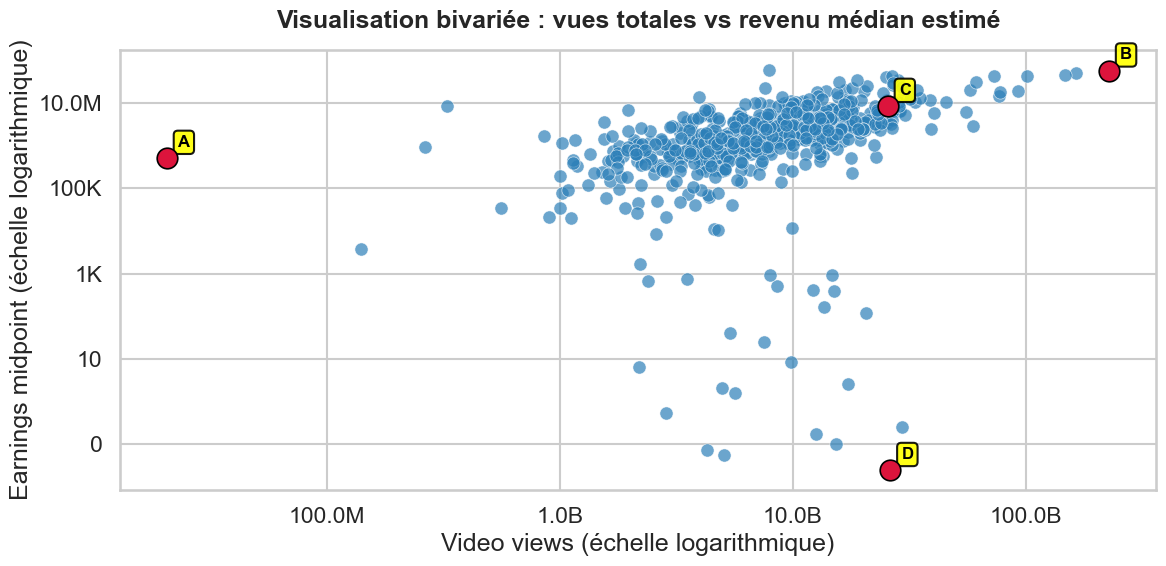


Point A
Youtuber               Vibhu 96
Country                   India
video views          20563378.0
earnings_midpoint      516750.0
Name: 852, dtype: object

Point B
Youtuber                   T-Series
Country                       India
video views          228000000000.0
earnings_midpoint        57600000.0
Name: 0, dtype: object

Point C
Youtuber             Genevieve's Playhouse - Learning Videos for Kids
Country                                                 United States
video views                                             25607397308.0
earnings_midpoint                                           8550000.0
Name: 112, dtype: object

Point D
Youtuber             5-Minute Crafts
Country               United Kingdom
video views            26236790209.0
earnings_midpoint              0.025
Name: 16, dtype: object


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# --- Sécurité : on garde seulement les valeurs positives pour l'échelle log ---
plot_df = df_sel[
    (df_sel["video views"] > 0) &
    (df_sel["earnings_midpoint"] > 0)
].copy()

# -------------------------------------------------
# Sélection automatique de 4 exemples :
# A : vues relativement "faibles"
# B : vues très élevées
# C et D : vues proches, revenus différents
# -------------------------------------------------

# A = parmi les plus faibles vues
A_idx = plot_df["video views"].idxmin()

# B = parmi les plus fortes vues
B_idx = plot_df["video views"].idxmax()

# Pour C et D : on cherche 2 chaînes avec des vues proches mais revenus différents
temp = plot_df.drop(index=[A_idx, B_idx]).copy()
temp = temp.sort_values("video views").reset_index()

best_pair = None
best_score = -1

for i in range(len(temp) - 1):
    x1 = temp.loc[i, "video views"]
    x2 = temp.loc[i + 1, "video views"]
    y1 = temp.loc[i, "earnings_midpoint"]
    y2 = temp.loc[i + 1, "earnings_midpoint"]

    # vues proches en échelle log
    x_close = abs(np.log10(x1) - np.log10(x2))

    # revenus différents en échelle log
    y_diff = abs(np.log10(y1) - np.log10(y2))

    # on veut x proche et y différent
    score = y_diff - x_close

    if x_close < 0.08 and score > best_score:
        best_score = score
        best_pair = (temp.loc[i, "index"], temp.loc[i + 1, "index"])

# Si aucune bonne paire n'est trouvée, on prend deux points autour de la médiane des vues
if best_pair is None:
    temp2 = temp.iloc[(len(temp)//2)-1:(len(temp)//2)+1]
    C_idx, D_idx = temp2["index"].tolist()
else:
    C_idx, D_idx = best_pair

examples = {
    "A": A_idx,
    "B": B_idx,
    "C": C_idx,
    "D": D_idx
}

# -------------------------------------------------
# Graphique
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))

sns.scatterplot(
    data=plot_df,
    x="video views",
    y="earnings_midpoint",
    color="#2c7fb8",
    s=90,
    alpha=0.70,
    edgecolor="white",
    linewidth=0.5,
    ax=ax
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.xaxis.set_major_formatter(FuncFormatter(human_format))
ax.yaxis.set_major_formatter(FuncFormatter(human_format))

ax.set_title("Visualisation bivariée : vues totales vs revenu médian estimé", pad=16, weight="bold")
ax.set_xlabel("Video views (échelle logarithmique)")
ax.set_ylabel("Earnings midpoint (échelle logarithmique)")

# -------------------------------------------------
# Ajouter les points A, B, C, D
# -------------------------------------------------
for label, idx in examples.items():
    row = plot_df.loc[idx]
    x = row["video views"]
    y = row["earnings_midpoint"]

    # point mis en évidence
    ax.scatter(
        x, y,
        s=220,
        color="crimson",
        edgecolor="black",
        linewidth=1.2,
        zorder=5
    )

    # annotation
    ax.annotate(
        label,
        (x, y),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=12,
        fontweight="bold",
        color="black",
        bbox=dict(boxstyle="round,pad=0.25", fc="yellow", ec="black", alpha=0.9)
    )

plt.tight_layout()
plt.show()

# -------------------------------------------------
# Afficher les infos des points choisis
# -------------------------------------------------
cols_to_show = ["Youtuber", "Country", "video views", "earnings_midpoint"]
for label, idx in examples.items():
    print(f"\nPoint {label}")
    print(plot_df.loc[idx, cols_to_show])




### Interprétation

-On remarque une tendance générale croissante : quand le nombre de vues augmente, le revenu médian estimé augmente aussi.Cela veut dire que les chaînes qui ont beaucoup de vues ont souvent plus de chances de générer des revenus plus élevés.

-Mais les points ne sont pas tous parfaitement alignés : cela montre que deux chaînes ayant presque le même nombre de vues peuvent avoir des revenus différents.

Donc, les vues expliquent une grande partie du revenu, mais pas totalement.

--->Ce graphique montre qu’en général, plus une chaîne a de vues, plus son revenu estimé augmente. Cependant, ce lien n’est pas parfait, car d’autres facteurs influencent aussi le revenu.


<div style="border-left:6px solid #7fb3d5; padding:12px; background:#f4f8fb; border-radius:10px; max-width:98%">
<b>7) Visualisation multivariée : pays et population</b>
</div>


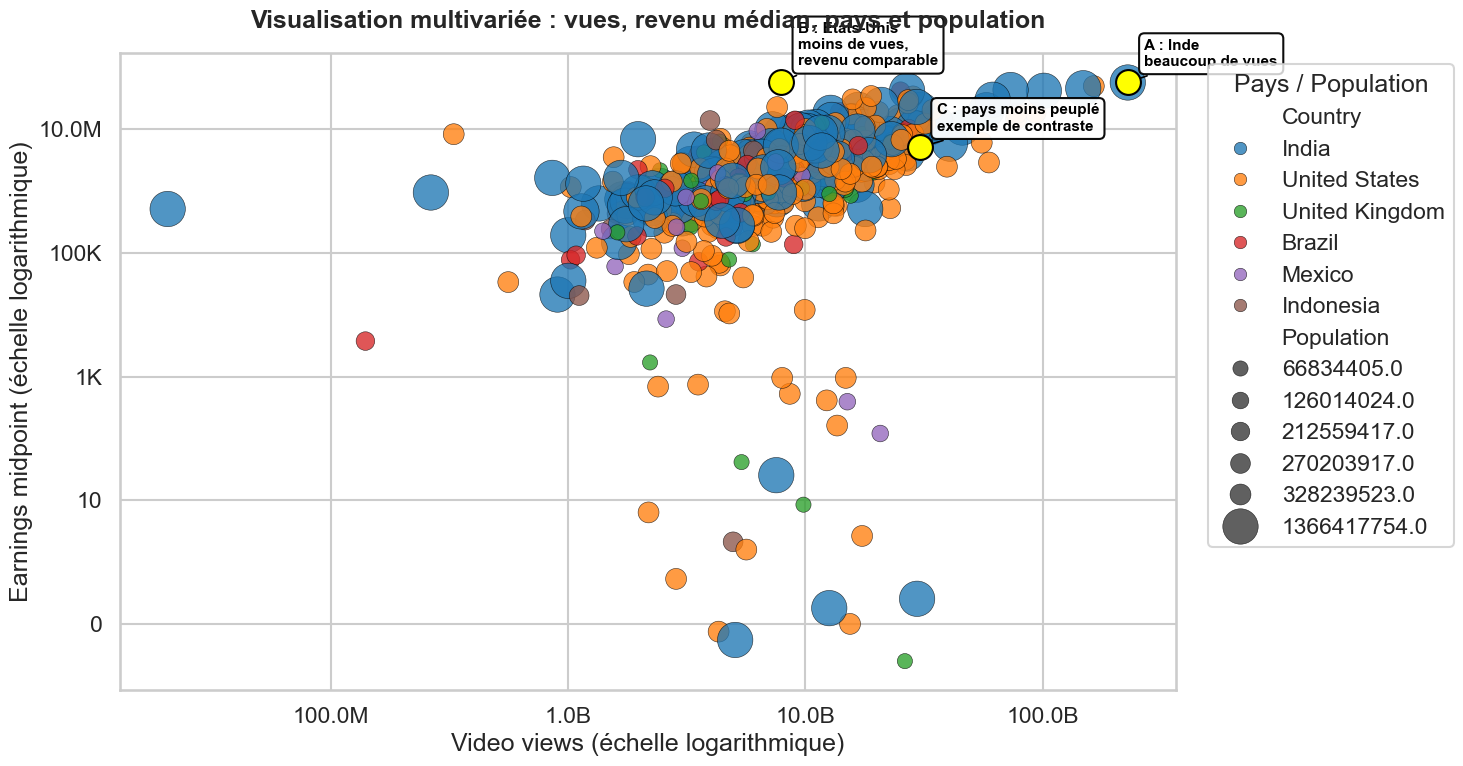


Point A
Youtuber                   T-Series
Country                       India
video views          228000000000.0
earnings_midpoint        57600000.0
Population             1366417754.0
Name: 0, dtype: object

Point B
Youtuber              DaFuq!?Boom!
Country              United States
video views           7906181776.0
earnings_midpoint       58750000.0
Population             328239523.0
Name: 417, dtype: object

Point C
Youtuber                 Ed Sheeran
Country              United Kingdom
video views           30367676736.0
earnings_midpoint         5154100.0
Population               66834405.0
Name: 39, dtype: object


In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# -------------------------------------------------
# 1) Préparer les données
# -------------------------------------------------
plot_df = df_sel[
    (df_sel["video views"] > 0) &
    (df_sel["earnings_midpoint"] > 0) &
    (df_sel["Population"] > 0)
].copy()

# -------------------------------------------------
# 2) Chercher automatiquement des exemples
# -------------------------------------------------

# A : une chaîne en Inde avec beaucoup de vues
india_df = plot_df[plot_df["Country"] == "India"].copy()
if not india_df.empty:
    A_idx = india_df["video views"].idxmax()
else:
    A_idx = plot_df["video views"].idxmax()

A_row = plot_df.loc[A_idx]

# B : une chaîne aux États-Unis avec moins de vues que A
# mais un revenu comparable ou supérieur
us_df = plot_df[plot_df["Country"] == "United States"].copy()

B_idx = None
if not us_df.empty:
    candidates = us_df[
        (us_df["video views"] < A_row["video views"]) &
        (us_df["earnings_midpoint"] >= 0.8 * A_row["earnings_midpoint"])
    ].copy()

    if not candidates.empty:
        # prendre celle avec le revenu le plus élevé
        B_idx = candidates["earnings_midpoint"].idxmax()
    else:
        # sinon prendre une chaîne US marquante
        B_idx = us_df["earnings_midpoint"].idxmax()

B_row = plot_df.loc[B_idx] if B_idx is not None else None

# C : un exemple de pays moins peuplé que l'Inde
# ici Royaume-Uni si disponible, sinon plus petite population parmi les pays sélectionnés
uk_df = plot_df[plot_df["Country"] == "United Kingdom"].copy()
if not uk_df.empty:
    C_idx = uk_df["video views"].idxmax()
else:
    temp = plot_df[plot_df["Country"] != "India"].copy()
    C_idx = temp["Population"].idxmin() if not temp.empty else plot_df["Population"].idxmin()

C_row = plot_df.loc[C_idx]

examples = {
    "A": A_idx,
    "B": B_idx,
    "C": C_idx
}

example_text = {
    "A": "A : Inde\nbeaucoup de vues",
    "B": "B : États-Unis\nmoins de vues,\nrevenu comparable",
    "C": "C : pays moins peuplé\nexemple de contraste"
}

# -------------------------------------------------
# 3) Graphique principal
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(15, 8))

palette = sns.color_palette("tab10", n_colors=plot_df["Country"].nunique())

sns.scatterplot(
    data=plot_df,
    x="video views",
    y="earnings_midpoint",
    hue="Country",
    size="Population",
    palette=palette,
    sizes=(120, 650),
    alpha=0.78,
    edgecolor="black",
    linewidth=0.4,
    ax=ax
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.xaxis.set_major_formatter(FuncFormatter(human_format))
ax.yaxis.set_major_formatter(FuncFormatter(human_format))

ax.set_title("Visualisation multivariée : vues, revenu médian, pays et population", pad=18, weight="bold")
ax.set_xlabel("Video views (échelle logarithmique)")
ax.set_ylabel("Earnings midpoint (échelle logarithmique)")

# -------------------------------------------------
# 4) Ajouter les exemples A, B, C
# -------------------------------------------------
for label, idx in examples.items():
    if idx is None:
        continue

    row = plot_df.loc[idx]
    x = row["video views"]
    y = row["earnings_midpoint"]

    ax.scatter(
        x, y,
        s=320,
        color="yellow",
        edgecolor="black",
        linewidth=1.5,
        zorder=6
    )

    ax.annotate(
        example_text[label],
        (x, y),
        xytext=(12, 12),
        textcoords="offset points",
        fontsize=11,
        fontweight="bold",
        color="black",
        bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="black", alpha=0.95),
        arrowprops=dict(arrowstyle="->", color="black", lw=1.2)
    )

legend = ax.legend(
    title="Pays / Population",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True
)

plt.tight_layout()
plt.show()

# -------------------------------------------------
# 5) Afficher les exemples choisis
# -------------------------------------------------
cols_to_show = ["Youtuber", "Country", "video views", "earnings_midpoint", "Population"]

for label, idx in examples.items():
    if idx is not None:
        print(f"\nPoint {label}")
        print(plot_df.loc[idx, cols_to_show])


## interpretation: 

Le revenu dépend des vues, mais le pays et la population peuvent aussi influencer la situation.

Les points annotés permettent de mieux comprendre le graphique. Le point A montre qu’une chaîne située dans un pays très peuplé comme l’Inde peut accumuler beaucoup de vues. Le point B montre qu’une chaîne américaine peut parfois obtenir un revenu comparable avec moins de vues, ce qui suggère une meilleure monétisation. Le point C sert de comparaison avec un pays moins peuplé.


<div style="border-left:6px solid #7fb3d5; padding:12px; background:#f4f8fb; border-radius:10px; max-width:98%">
<b>8) Facettes par pays</b>
</div>

Les facettes permettent de comparer les pays un par un.  
Ici, chaque sous-graphe représente un pays sélectionné. La couleur indique le type de chaîne.


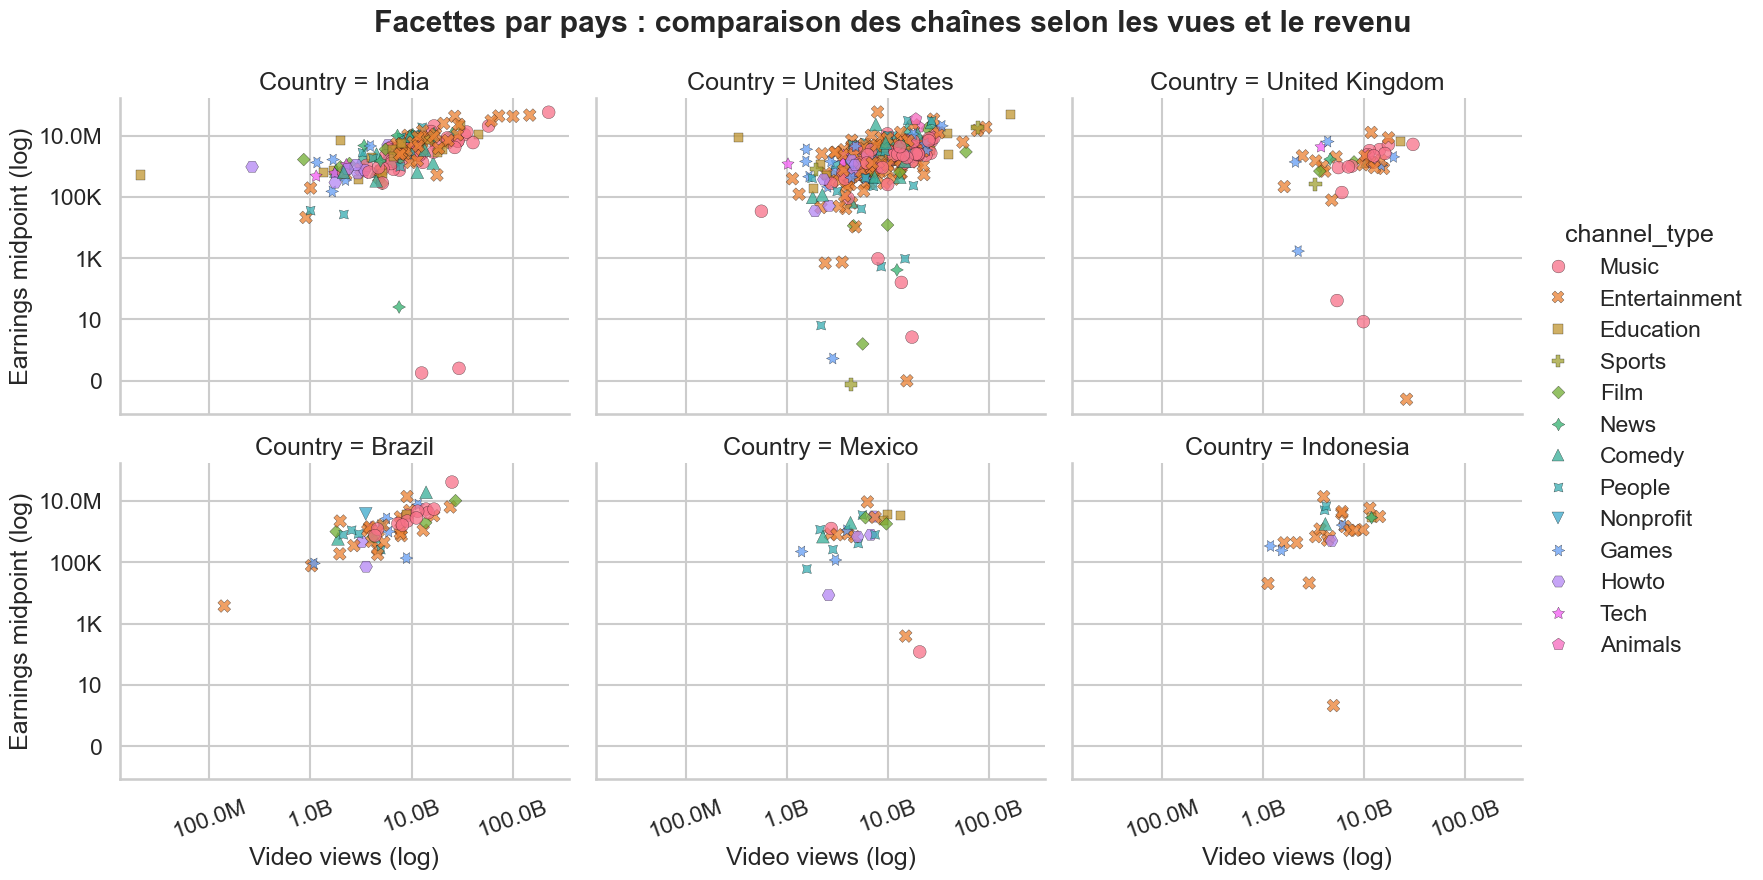

In [20]:

g = sns.relplot(
    data=df_sel,
    x="video views",
    y="earnings_midpoint",
    col="Country",
    col_wrap=3,
    hue="channel_type",
    style="channel_type",
    kind="scatter",
    height=4.4,
    aspect=1.15,
    alpha=0.75,
    s=85,
    edgecolor="black",
    linewidth=0.25
)

for ax in g.axes.flat:
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.xaxis.set_major_formatter(FuncFormatter(human_format))
    ax.yaxis.set_major_formatter(FuncFormatter(human_format))
    ax.tick_params(axis="x", rotation=20)

g.set_axis_labels("Video views (log)", "Earnings midpoint (log)")
g.fig.subplots_adjust(top=0.88)
g.fig.suptitle("Facettes par pays : comparaison des chaînes selon les vues et le revenu", weight="bold")

plt.show()


## interpretation


1- Plus il y a de points dans une facette, plus ce pays a de chaînes dans le dataset sélectionné.
Par exemple, la facette India contient beaucoup de points, donc beaucoup de chaînes indiennes sont présentes dans le dataset, alors que la facette United Kingdom en contient moins.

2-Quand les points sont proches les uns des autres, les chaînes ont des niveaux de vues et de revenus assez similaires.
Par exemple, dans Mexico, les points sont relativement regroupés, ce qui suggère que plusieurs chaînes ont des performances assez semblables.

3-Quand les points sont très éloignés, cela veut dire que les chaînes d’un même pays n’ont pas toutes le même comportement.
Par exemple, dans United States, les points sont plus dispersés, ce qui montre que les revenus varient fortement d’une chaîne à l’autre.


<div style="border-left:6px solid #7fb3d5; padding:12px; background:#f4f8fb; border-radius:10px; max-width:98%">
<b>10) Proposition des décisions</b>
</div>

### Proposition des décisions

À partir de cette analyse, on peut proposer les décisions suivantes :

1. **Ne pas évaluer une chaîne uniquement par son nombre de vues.**  
   Il faut aussi tenir compte du pays et du contexte de monétisation.

2. **Segmenter l'analyse par pays.**  
   La comparaison globale masque des différences importantes entre marchés nationaux.

3. **Prioriser les pays les plus rentables à volume de vues comparable.**  
   Cela peut aider à définir une stratégie de ciblage ou d'expansion.

4. **Compléter cette étude par d'autres variables explicatives.**  
   Par exemple : `channel_type`, `subscribers`, `video_views_for_the_last_30_days` ou les revenus mensuels.

5. **Construire un tableau de bord multivarié.**  
   Ce tableau de bord pourrait suivre simultanément les vues, les revenus, le pays, la population et le type de chaîne pour soutenir la prise de décision.



<div style="border-left:6px solid #7fb3d5; padding:12px; background:#f4f8fb; border-radius:10px; max-width:98%">
<b>11) Conclusion</b>
</div>

Cette visualisation multivariée montre que le revenu d'une chaîne YouTube dépend bien du volume de vues, mais que le **pays** et, plus largement, le **contexte géographique** semblent aussi influencer la relation.  
La population apporte un **cadre d'interprétation**, tandis que les facettes rendent la comparaison entre pays plus claire et plus présentable.


## Analyse des performances des 30 derniers jours de la période observée

<div style="border-left:6px solid #8cc6ed; padding:12px; background:#f4f8fb; border-radius:10px; max-width:98%">

#### **Analyser des profils multivariés** </div>

<div style="border-left:6px solid #c5cace; padding:11px; background:#f4f8fb; border-radius:10px; max-width:98%">

#### **Parallel coordinates** </div>

In [21]:
from pandas.plotting import parallel_coordinates

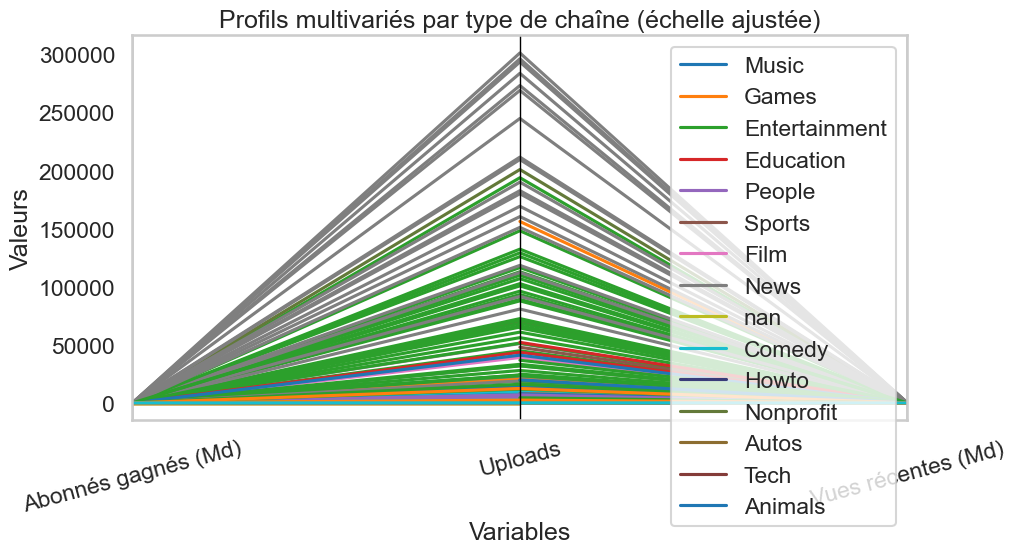

In [22]:
# conversion en milliards pour améliorer la lisibilité des variables de volume

df_parallel = df[["channel_type","subscribers_for_last_30_days","uploads","video_views_for_the_last_30_days"]].copy()
df_parallel["subscribers_for_last_30_days"] = df_parallel["subscribers_for_last_30_days"] / 1e9
df_parallel["video_views_for_the_last_30_days"] = df_parallel["video_views_for_the_last_30_days"] / 1e9

plt.figure(figsize=(10,5))

parallel_coordinates(
    df_parallel,
    class_column="channel_type",
    color=[
        "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728",
        "#9467bd", "#8c564b", "#e377c2", "#7f7f7f",
        "#bcbd22", "#17becf", "#393b79", "#637939",
        "#8c6d31", "#843c39"
    ]
)

plt.title("Profils multivariés par type de chaîne (échelle ajustée)")
plt.xlabel("Variables")
plt.ylabel("Valeurs")
plt.xticks(
    ticks=range(3),
    labels=["Abonnés gagnés (Md)", "Uploads", "Vues récentes (Md)"],
    rotation=15
)

plt.show()


**Observations — graphique 1 :**

- Les variables liées aux abonnés et aux vues ont été transformées en **milliards (Md)**, ce qui rend la lecture de l’échelle plus cohérente.
- Même après cet ajustement, les profils restent dispersés : cela confirme une forte hétérogénéité entre les types de chaînes.
- Les volumes d’uploads restent sur une logique différente, ce qui montre que la comparaison brute doit être interprétée avec prudence.

C:\Users\hp\AppData\Local\Temp\ipykernel_14352\87127708.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), 20), random_state=42))


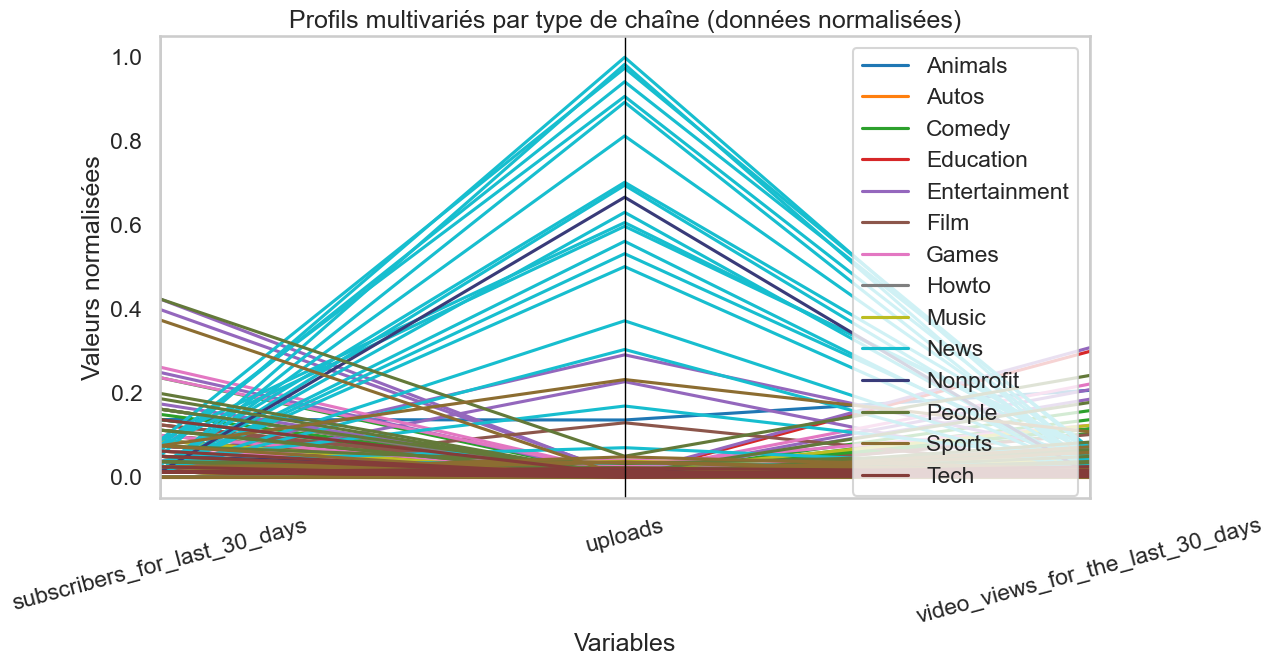

In [23]:
from sklearn.preprocessing import MinMaxScaler

# normalisation
cols = ["subscribers_for_last_30_days", "uploads", "video_views_for_the_last_30_days"]
scaler = MinMaxScaler()
df_scaled = df.dropna(subset=cols + ["channel_type"]).copy()
df_scaled[cols] = scaler.fit_transform(df_scaled[cols])

# échantillon pour améliorer la lisibilité
df_sample = (
    df_scaled.groupby("channel_type", group_keys=False)
    .apply(lambda x: x.sample(min(len(x), 20), random_state=42))
)

# plot
plt.figure(figsize=(12,6))

parallel_coordinates(
    df_sample[cols + ["channel_type"]],
    class_column="channel_type",
    color=[
        "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728",
        "#9467bd", "#8c564b", "#e377c2", "#7f7f7f",
        "#bcbd22", "#17becf", "#393b79", "#637939",
        "#8c6d31", "#843c39"
    ]
)

plt.title("Profils multivariés par type de chaîne (données normalisées)")
plt.xlabel("Variables")
plt.ylabel("Valeurs normalisées")
plt.xticks(rotation=15)

plt.show()

**Observations — graphique 2 :**

- Après normalisation, la comparaison entre types de chaînes devient plus lisible.
- On observe que certaines catégories combinent davantage de vues récentes et de gains d’abonnés, alors que d’autres se distinguent surtout par le volume d’uploads.
- La normalisation confirme que la performance récente ne dépend pas uniquement de la fréquence de publication.


<div style="border-left:6px solid #c5cace; padding:11px; background:#f4f8fb; border-radius:10px; max-width:98%">

#### **Nuage de points multivarié (Scatter plot)** </div>


In [25]:
top_countries = df["Country"].value_counts().head(5).index
df_top = df[df["Country"].isin(top_countries)]

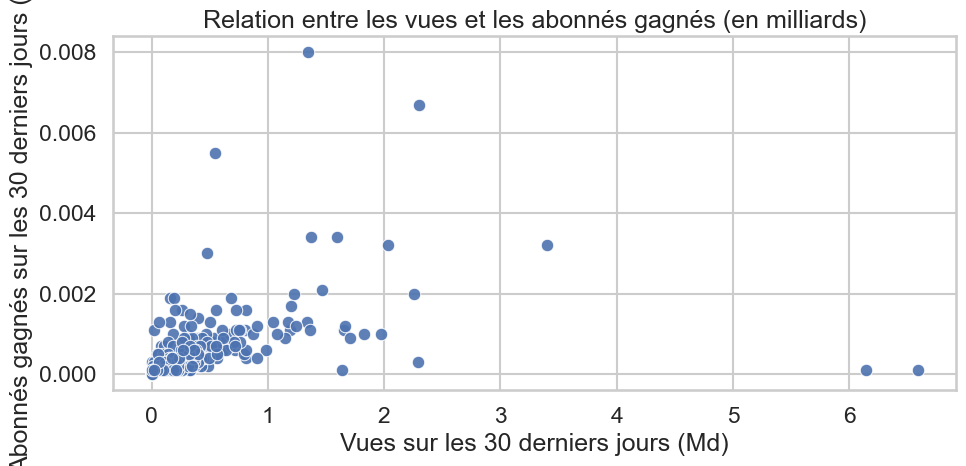

In [26]:
# conversion en milliards pour les axes du nuage de points

df_scatter = df.copy()
df_scatter["video_views_for_the_last_30_days_billion"] = df_scatter["video_views_for_the_last_30_days"] / 1e9
df_scatter["subscribers_for_last_30_days_billion"] = df_scatter["subscribers_for_last_30_days"] / 1e9

plt.figure(figsize=(10,5))

sns.scatterplot(
    data=df_scatter,
    x="video_views_for_the_last_30_days_billion",
    y="subscribers_for_last_30_days_billion",
    alpha=0.9
)

plt.title("Relation entre les vues et les abonnés gagnés (en milliards)")
plt.xlabel("Vues sur les 30 derniers jours (Md)")
plt.ylabel("Abonnés gagnés sur les 30 derniers jours (Md)")

plt.tight_layout()
plt.show()


**Observations — graphique 3 :**

- Le passage en **milliards (Md)** rend l’échelle plus lisible et facilite l’interprétation des écarts entre chaînes.
- La relation entre les vues récentes et les abonnés gagnés reste globalement positive.
- La dispersion importante indique toutefois que la conversion des vues en abonnés n’est pas identique pour toutes les chaînes.

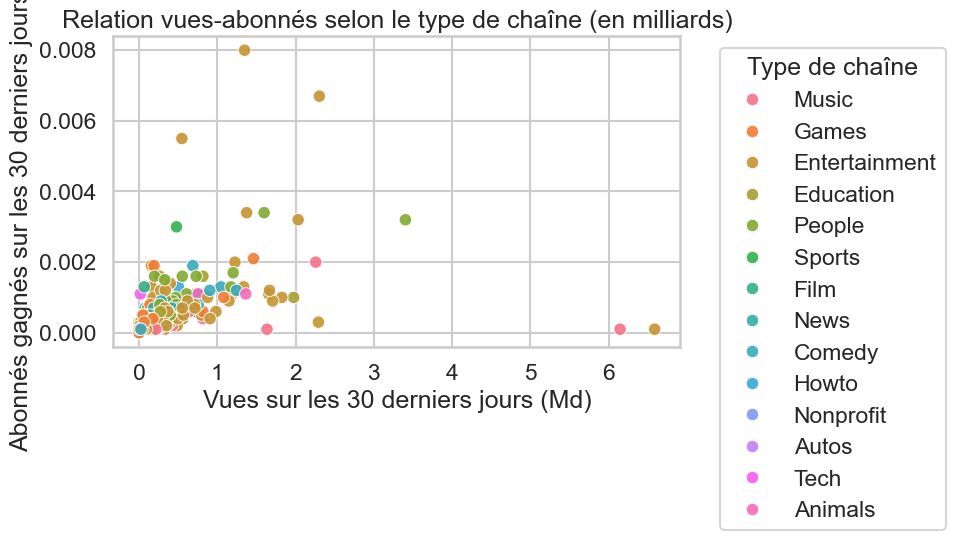

In [27]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    data=df_scatter,
    x="video_views_for_the_last_30_days_billion",
    y="subscribers_for_last_30_days_billion",
    hue="channel_type",
    alpha=0.9
)

plt.title("Relation vues-abonnés selon le type de chaîne (en milliards)")
plt.xlabel("Vues sur les 30 derniers jours (Md)")
plt.ylabel("Abonnés gagnés sur les 30 derniers jours (Md)")

plt.legend(title="Type de chaîne", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


**Observations — graphique 4 :**

- L’ajout de la couleur montre que les performances ne sont pas uniformes selon le type de chaîne.
- Les catégories dominantes, notamment *Entertainment* et *Music*, occupent une large partie de l’espace et semblent concentrer les plus fortes performances récentes.
- D’autres catégories apparaissent plus dispersées ou plus modestes, ce qui peut refléter des audiences plus spécialisées.

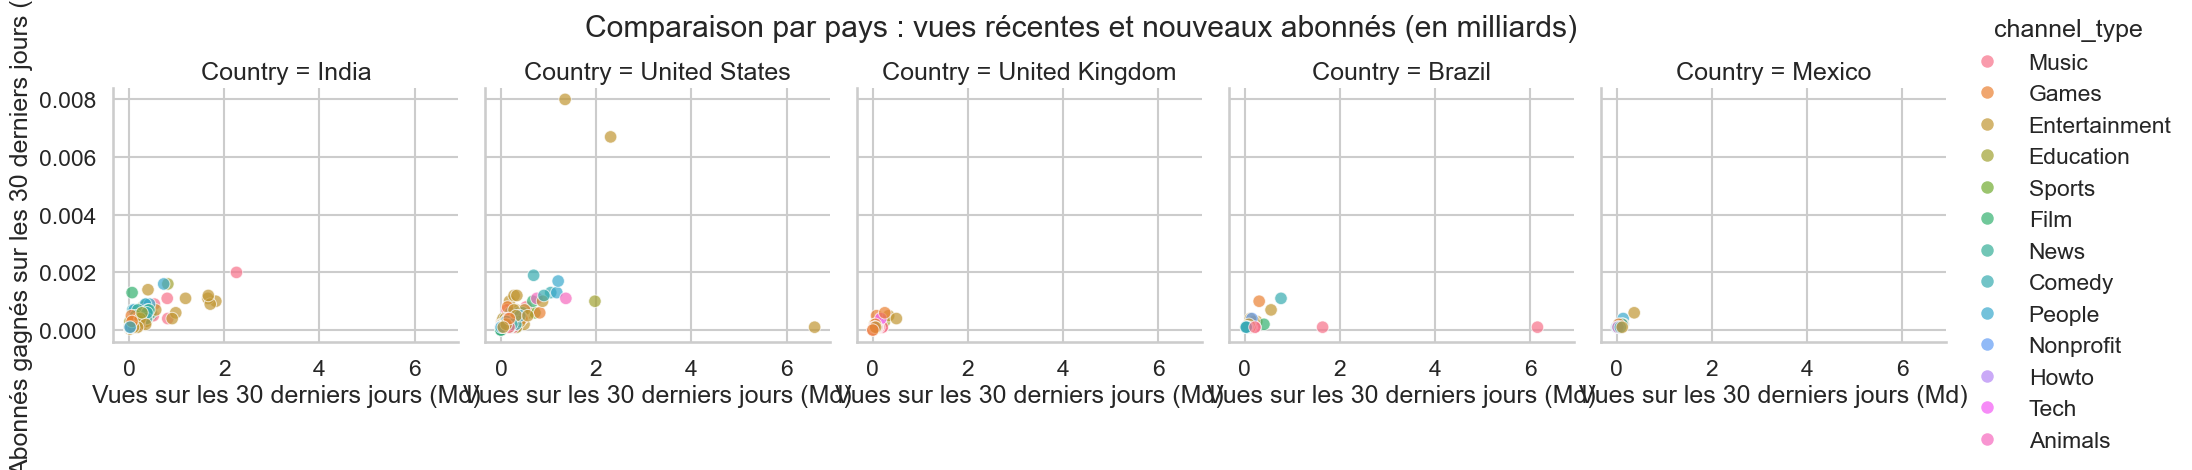

In [28]:
df_top_plot = df_top.copy()
df_top_plot["video_views_for_the_last_30_days_billion"] = df_top_plot["video_views_for_the_last_30_days"] / 1e9
df_top_plot["subscribers_for_last_30_days_billion"] = df_top_plot["subscribers_for_last_30_days"] / 1e9

g = sns.relplot(
    data=df_top_plot,
    x="video_views_for_the_last_30_days_billion",
    y="subscribers_for_last_30_days_billion",
    hue="channel_type",
    col="Country",
    alpha=0.7,
    height=4
)

g.fig.suptitle("Comparaison par pays : vues récentes et nouveaux abonnés (en milliards)", y=1.05)
g.set_axis_labels("Vues sur les 30 derniers jours (Md)", "Abonnés gagnés sur les 30 derniers jours (Md)")

plt.show()


**Observations — graphique 5 :**

- La facettisation par pays montre que la relation vues-abonnés existe dans plusieurs contextes géographiques, mais avec des intensités différentes.
- Les pays les plus représentés présentent aussi la plus grande variabilité, ce qui traduit la diversité des chaînes présentes dans ces marchés.
- La structure par pays suggère que le contexte géographique complète l’effet du type de chaîne dans l’explication des performances.

<div style="border-left:6px solid ; padding:12px; border-radius:10px; max-width:98%">

#### **Décision finale**

L’analyse multivariée montre que les **vues des 30 derniers jours** sont le facteur le plus directement associé aux **abonnés gagnés sur la même période**. Les performances varient ensuite selon le **type de chaîne** et, dans une moindre mesure, selon le **pays**. En revanche, le nombre d’**uploads** n’explique pas à lui seul les meilleurs résultats.